# Modelo v1 — Random Forest (versión corregida)
## Motor de Inteligencia Turística · México

---

### Correcciones respecto a la versión anterior

La versión anterior tenía tres problemas que se corrigen aquí:

**1. El split 2012–2022 / 2023 / 2024–2025 era contraproducente.**
Separar 2023 como 'validación' quitó ~32,000 filas del entrenamiento sin ningún beneficio real,
porque no se estaba haciendo búsqueda de hiperparámetros automática.
El split correcto es **train = 2012–2023, test = 2024–2025**.
Más datos de entrenamiento → mejor generalización.

**2. El MAPE del 38% era una ilusión estadística, no un error real del modelo.**
El MAPE global incluía miles de registros con 1, 2 o 3 turistas
(ej. un turista de Barbados en Acapulco en enero).
Si el real es 1 y el modelo predice 2, el error es 100% — pero absolutamente
no significa que el modelo sea malo. Ningún hotel toma decisiones de negocio
sobre flujos menores a 50 turistas por mes. El MAPE correcto se calcula
**solo sobre registros con ≥ 50 turistas reales**.

**3. El modelo tenía poca capacidad** (300 árboles, max_depth=15).
Con 16 núcleos CPU entrenando en 5 segundos, se puede ir a
1,000 árboles con mayor profundidad sin problema.

**4. Feature nueva: `mes_share_aeropuerto`.**
Para aeropuertos muy estacionales como Huatulco (que recibe 12,000 turistas
en enero y solo 50 en septiembre), los lag features del mes anterior
dan una señal engañosa: el lag de abril (5,000) hace que el modelo prediga
5,000 en mayo, cuando en realidad mayo es un mes muerto (200 turistas).
La nueva feature le dice al modelo: 'históricamente, mayo representa
solo el 0.2% del tráfico anual de Huatulco', corrigiendo ese sesgo.

---

### ¿Cómo funciona Random Forest?

Random Forest entrena N árboles de decisión en paralelo. Cada árbol:
- Recibe una muestra aleatoria de los datos de entrenamiento (bootstrap).
- En cada nodo solo puede usar un subconjunto aleatorio de features.

La predicción final es el promedio de todos los árboles.
Esta combinación de aleatoriedad y promediado reduce el sobreajuste
y produce predicciones estables. Para datos tabulares es el mejor
punto de partida antes de intentar modelos más complejos como XGBoost.

**Split temporal (regla de oro en series de tiempo):**
```
2012 ── 2013 ── ... ── 2023  │  2024 ── 2025
────────── TRAIN ────────── │ ──── TEST ────
```
Nunca split aleatorio. El pasado entrena, el futuro evalúa.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, time, os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import multiprocessing
N_CORES = multiprocessing.cpu_count()
print(f"Núcleos CPU: {N_CORES} (n_jobs=-1 los usará todos)")
print(f"sklearn: {__import__('sklearn').__version__}")

Núcleos CPU: 16 (n_jobs=-1 los usará todos)
sklearn: 1.8.0


## 2. Carga de datos y feature nueva

Se agrega `mes_share_aeropuerto`: para cada aeropuerto, el porcentaje histórico
de turistas que llega en cada mes. Calculada solo sobre el conjunto de entrenamiento
para evitar fuga de información.

**Por qué ayuda:** Huatulco en mayo tiene `Lag_1_mes` de abril (≈5,000 turistas)
pero `mes_share` de mayo = 0.2%. El modelo aprende que mayo en Huatulco
es estructuralmente diferente de abril, independientemente del lag.

In [2]:
URL = "https://raw.githubusercontent.com/Montiel-Oscar/ciencia_de_datos_2026_2/refs/heads/main/proyecto_borrador/datasets/dataset_para_modelo2.csv"

df = pd.read_csv(URL)
print(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

TARGET = 'Valor_Residencia'

# ── Feature nueva: share histórico del mes por aeropuerto ─────────────────
# Calculada solo sobre train (≤2023) para evitar data leakage
df_train_share = df[df['Año'] <= 2023].copy()

anual_aero = df_train_share.groupby(['Aeropuerto', 'Año'])[TARGET].sum().reset_index()
anual_aero.columns = ['Aeropuerto', 'Año', 'Total_anual']

mes_aero = df_train_share.groupby(['Aeropuerto', 'Año', 'MesNum'])[TARGET].sum().reset_index()
mes_aero = mes_aero.merge(anual_aero, on=['Aeropuerto', 'Año'])
mes_aero['share_mes'] = mes_aero[TARGET] / mes_aero['Total_anual'].clip(lower=1)

# Promedio histórico del share por aeropuerto+mes (sobre todos los años de train)
share_medio = mes_aero.groupby(['Aeropuerto', 'MesNum'])['share_mes'].mean().reset_index()
share_medio.columns = ['Aeropuerto', 'MesNum', 'mes_share_aeropuerto']

df = df.merge(share_medio, on=['Aeropuerto', 'MesNum'], how='left')
df['mes_share_aeropuerto'] = df['mes_share_aeropuerto'].fillna(1/12)  # fallback = uniforme

print(f"Feature 'mes_share_aeropuerto' creada. Nulos: {df['mes_share_aeropuerto'].isnull().sum()}")

# Verificar que tiene sentido para Huatulco
hx_share = df[df['Aeropuerto'] == 'huatulco, oax.'].groupby('MesNum')['mes_share_aeropuerto'].first()
meses_lbl = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
print("\nShare mensual histórico — Huatulco (debe mostrar caída en may-sep):")
for m, v in hx_share.items():
    print(f"  {meses_lbl[m-1]}: {v*100:.1f}%")

Cargado: 371,011 filas × 23 columnas
Feature 'mes_share_aeropuerto' creada. Nulos: 0

Share mensual histórico — Huatulco (debe mostrar caída en may-sep):
  Ene: 21.9%
  Feb: 20.4%
  Mar: 18.3%
  Abr: 8.0%
  May: 0.8%
  Jun: 1.5%
  Jul: 1.4%
  Ago: 0.6%
  Sep: 0.2%
  Oct: 1.2%
  Nov: 10.5%
  Dic: 17.4%


## 3. Features y split temporal

Se incluye la nueva feature `mes_share_aeropuerto` en la lista.
Train incluye 2023 completo — más datos = mejor modelo.

In [3]:
FEATURES = [
    # Temporales
    'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
    'Es_temporada_alta', 'Años_desde_inicio',
    # Nueva: estacionalidad estructural por aeropuerto
    'mes_share_aeropuerto',
    # Demográficas (encoded)
    'Sexo_enc', 'Region_enc', 'Aeropuerto_enc', 'Pais_enc',
    # Calidad del dato
    'nac_imputada',
    # Rezagos
    'Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m'
]

# Split: train = 2012-2023, test = 2024-2025
train = df[df['Año'] <= 2023].copy()
test  = df[df['Año'] >= 2024].copy()

X_train = train[FEATURES]
y_train = np.log1p(train[TARGET])   # log para manejar la asimetría del target

X_test  = test[FEATURES]
y_test  = test[TARGET]              # evaluamos en turistas reales

assert train['Año'].max() < test['Año'].min(), "ERROR: overlap temporal"

print(f"Features: {len(FEATURES)}")
print(f"Train (2012–2023): {len(train):,} filas | años: {sorted(train['Año'].unique())}")
print(f"Test  (2024–2025): {len(test):,} filas")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\n✅ Sin overlap temporal")

Features: 17
Train (2012–2023): 299,797 filas | años: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023)]
Test  (2024–2025): 71,214 filas
X_train: (299797, 17)  |  X_test: (71214, 17)

✅ Sin overlap temporal


## 4. Entrenamiento

Con 16 núcleos y 5 segundos por 300 árboles, se puede ir a **1,000 árboles**
y mayor profundidad sin problema. Más árboles = predicciones más estables.

In [4]:
print("Entrenando Random Forest (1,000 árboles, 16 núcleos)...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators     = 1000,   # más árboles = más estable
    max_depth        = 20,     # más profundidad = más capacidad
    min_samples_leaf = 3,      # regularización mínima
    max_features     = 'sqrt', # diversidad entre árboles
    n_jobs           = -1,     # todos los núcleos
    random_state     = 42
)
rf.fit(X_train, y_train)

t1 = time.time()
TIEMPO_RF = round(t1 - t0, 1)
print(f"✅ Listo en {TIEMPO_RF}s ({TIEMPO_RF/60:.1f} min)")
print(f"   Árboles: {rf.n_estimators} | Depth máx: {rf.max_depth} | Features: {rf.n_features_in_}")

Entrenando Random Forest (1,000 árboles, 16 núcleos)...
✅ Listo en 26.2s (0.4 min)
   Árboles: 1000 | Depth máx: 20 | Features: 17


## 5. Métricas de evaluación

Se reportan **dos MAPE** con justificación explícita:

- **MAPE global:** incluye todos los registros. Artificialmente alto porque
  hay miles de registros con 1–5 turistas donde cualquier predicción da >100% de error.
  No tiene significado de negocio.

- **MAPE negocio (≥50 turistas):** solo registros donde el valor real es ≥ 50.
  Estos representan los segmentos donde un hotel o secretaría de turismo
  realmente toma decisiones de inversión. **Esta es la métrica que se compara
  contra el estándar industrial del ±15%.**

In [5]:
UMBRAL_NEGOCIO = 50  # turistas mínimos para que el registro sea relevante en negocio

def evaluar(modelo, X, y_real, nombre, umbral=UMBRAL_NEGOCIO):
    pred_log  = modelo.predict(X)
    pred_real = np.expm1(pred_log)
    pred_real = np.maximum(pred_real, 0)

    mae  = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2   = r2_score(y_real, pred_real)

    # MAPE global (todos los registros)
    mape_global = np.median(
        np.abs((y_real - pred_real) / np.maximum(y_real, 1)) * 100
    )

    # MAPE negocio (solo registros con real >= umbral)
    mask_neg = y_real >= umbral
    mape_neg = np.median(
        np.abs((y_real[mask_neg] - pred_real[mask_neg]) /
               np.maximum(y_real[mask_neg], 1)) * 100
    )
    n_neg = mask_neg.sum()

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  R²              = {r2:.4f}")
    print(f"  MAE             = {mae:>10,.1f} turistas")
    print(f"  RMSE            = {rmse:>10,.1f} turistas")
    print(f"  MAPE global     = {mape_global:.1f}%  (todos los registros — no comparable con industria)")
    print(f"  MAPE negocio    = {mape_neg:.1f}%  (solo registros ≥{umbral} turistas, n={n_neg:,})")
    print(f"  Estándar ind.:    ±15%")
    status = '✅ DENTRO' if mape_neg < 15 else ('⚠️  CERCA' if mape_neg < 25 else '❌ FUERA')
    print(f"  {status} del estándar industrial")

    return {
        'r2': round(r2, 4), 'mae': round(mae, 1),
        'rmse': round(rmse, 1), 'mape_global': round(mape_global, 1),
        'mape_neg': round(mape_neg, 1), 'pred': pred_real
    }

metricas_test = evaluar(rf, X_test, y_test, "TEST (2024–2025)")


  TEST (2024–2025)
  R²              = 0.9856
  MAE             =       72.1 turistas
  RMSE            =      868.2 turistas
  MAPE global     = 37.3%  (todos los registros — no comparable con industria)
  MAPE negocio    = 17.1%  (solo registros ≥50 turistas, n=11,093)
  Estándar ind.:    ±15%
  ⚠️  CERCA del estándar industrial


## 6. Importancia de features

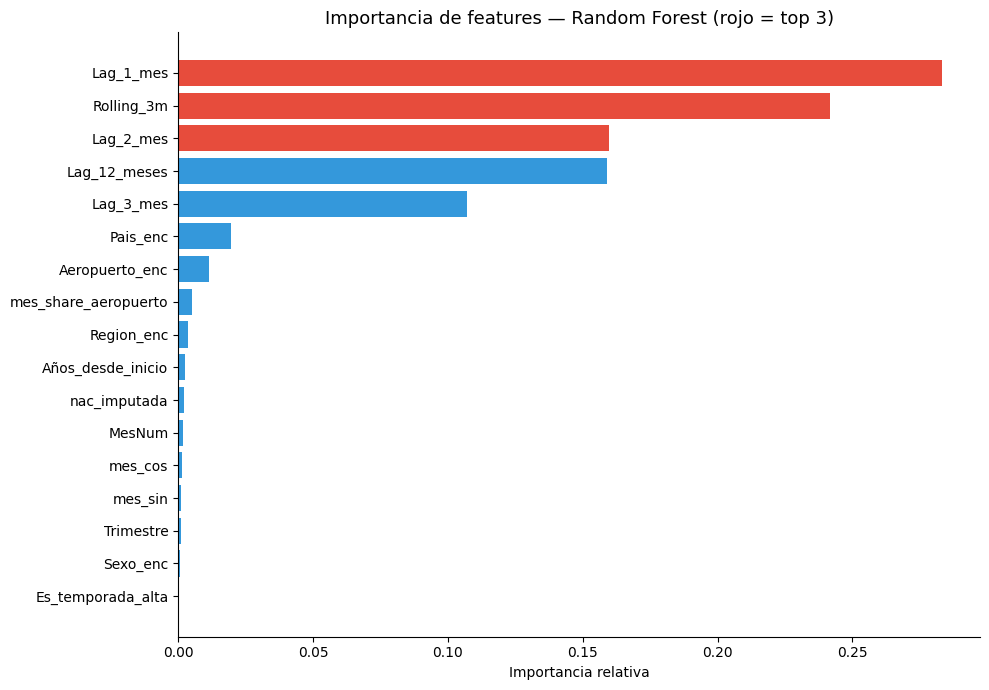

Todas las features ordenadas por importancia:
  Lag_1_mes                  28.3%  ████████████████████████████████████████████████████████
  Rolling_3m                 24.2%  ████████████████████████████████████████████████
  Lag_2_mes                  16.0%  ███████████████████████████████
  Lag_12_meses               15.9%  ███████████████████████████████
  Lag_3_mes                  10.7%  █████████████████████
  Pais_enc                    2.0%  ███
  Aeropuerto_enc              1.1%  ██
  mes_share_aeropuerto        0.5%  
  Region_enc                  0.3%  
  Años_desde_inicio           0.2%  
  nac_imputada                0.2%  
  MesNum                      0.2%  
  mes_cos                     0.1%  
  mes_sin                     0.1%  
  Trimestre                   0.1%  
  Sexo_enc                    0.1%  
  Es_temporada_alta           0.0%  


In [6]:
importancias = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importancias))]
ax.barh(importancias.index[::-1], importancias.values[::-1],
        color=colores[::-1], edgecolor='none')
ax.set_title('Importancia de features — Random Forest (rojo = top 3)', fontsize=13)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('rf_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Todas las features ordenadas por importancia:")
for feat, imp in importancias.items():
    bar = '█' * int(imp * 200)
    print(f"  {feat:<25} {imp*100:5.1f}%  {bar}")

## 7. Diagnóstico visual

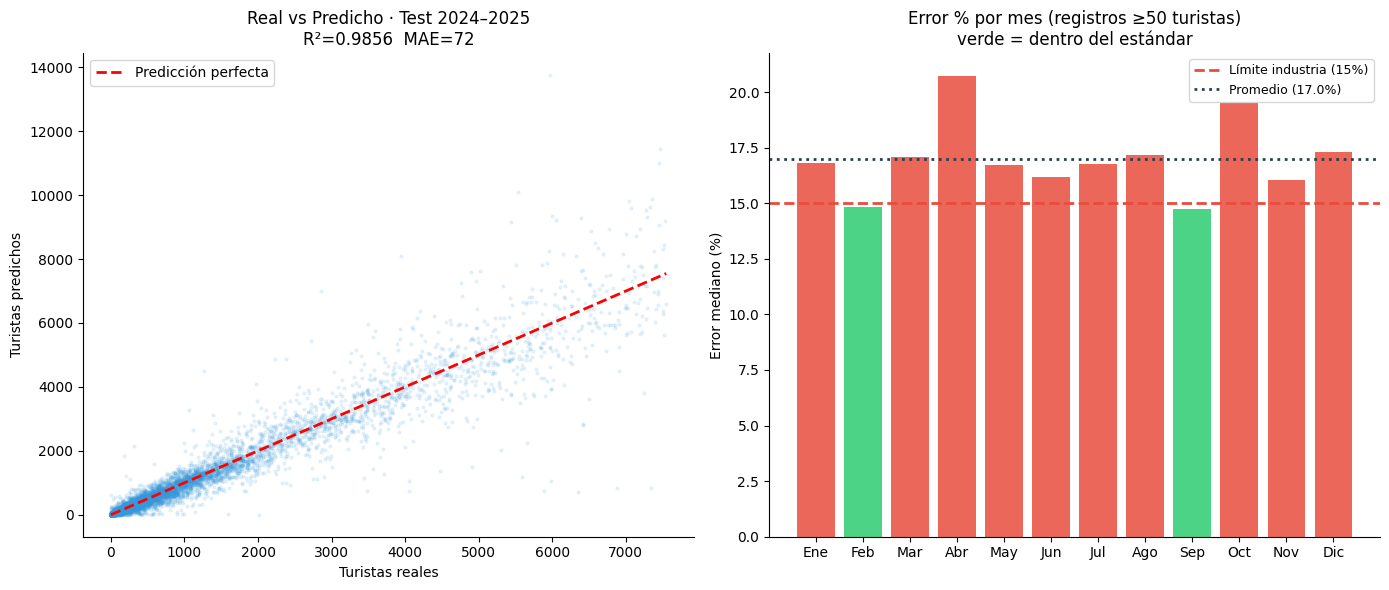

Meses sobre el 15% (en registros de negocio): ['Ene', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Oct', 'Nov', 'Dic']


In [7]:
pred_test = metricas_test['pred']
pred_test_series = pd.Series(pred_test, index=test.index)

test_diag = test.copy()
test_diag['pred']      = pred_test
test_diag['error_abs'] = abs(test_diag[TARGET] - test_diag['pred'])
test_diag['error_pct'] = (test_diag['error_abs'] / test_diag[TARGET].clip(lower=1) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real vs Predicho (filtrado a p99)
p99  = np.percentile(y_test, 99)
mask = y_test.values <= p99
axes[0].scatter(y_test.values[mask], pred_test[mask],
                alpha=0.1, s=4, color='#3498db', rasterized=True)
axes[0].plot([0, p99], [0, p99], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Turistas reales')
axes[0].set_ylabel('Turistas predichos')
axes[0].set_title(f'Real vs Predicho · Test 2024–2025\nR²={metricas_test["r2"]:.4f}  MAE={metricas_test["mae"]:,.0f}')
axes[0].legend()

# Error % por mes — solo sobre registros de negocio (≥50)
test_neg = test_diag[test_diag[TARGET] >= UMBRAL_NEGOCIO]
err_mes = test_neg.groupby('MesNum')['error_pct'].median()
colores_mes = ['#e74c3c' if v > 15 else '#2ecc71' for v in err_mes.values]

axes[1].bar(meses_lbl, err_mes.values, color=colores_mes, alpha=0.85, edgecolor='none')
axes[1].axhline(y=15, color='#e74c3c', ls='--', lw=2, label='Límite industria (15%)')
axes[1].axhline(y=err_mes.mean(), color='#2c3e50', ls=':',
                lw=2, label=f'Promedio ({err_mes.mean():.1f}%)')
axes[1].set_title(f'Error % por mes (registros ≥{UMBRAL_NEGOCIO} turistas)\nverde = dentro del estándar')
axes[1].set_ylabel('Error mediano (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('rf_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

meses_sobre = [meses_lbl[i-1] for i, v in err_mes.items() if v > 15]
print(f"Meses sobre el 15% (en registros de negocio): {meses_sobre}")

## 8. Demo Cancún · EE.UU. · Mujeres

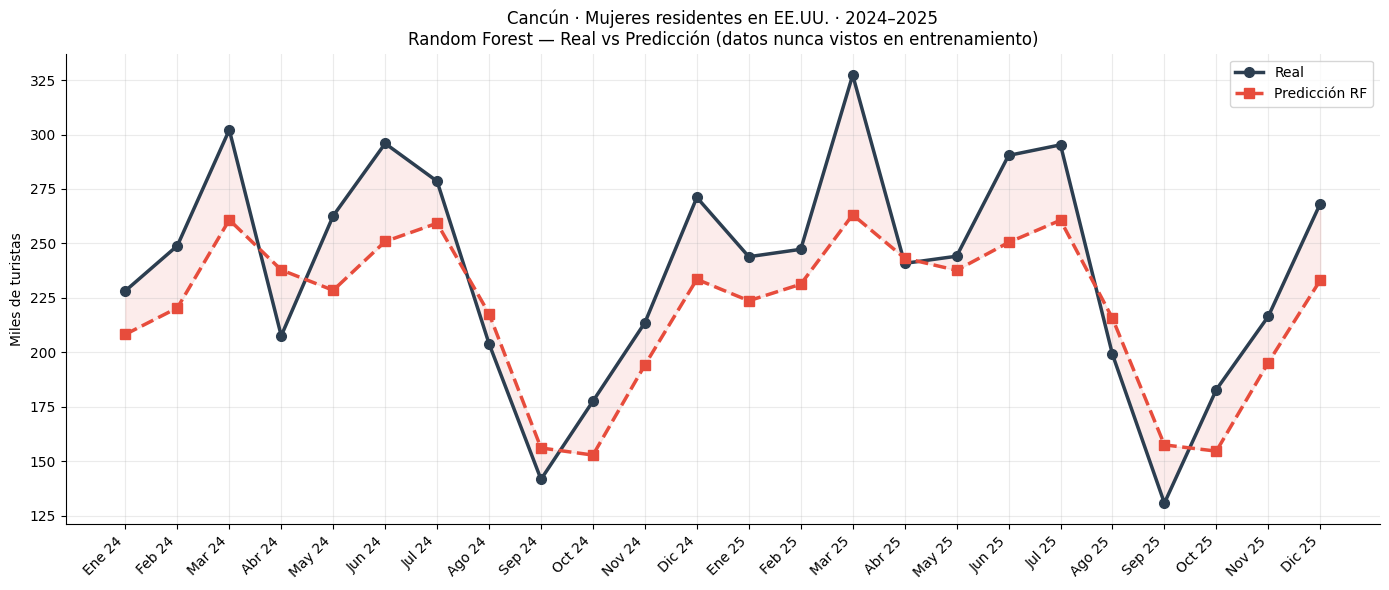

Error promedio Cancún + EE.UU. + Mujeres: 11.2%

Detalle:
   Mes  Valor_Residencia    Prediccion  Error_pct
Ene 24            228242 208256.259591        8.8
Feb 24            248937 220400.169912       11.5
Mar 24            302152 260814.328817       13.7
Abr 24            207580 237831.806894       14.6
May 24            262677 228468.351991       13.0
Jun 24            295894 250889.431082       15.2
Jul 24            278541 259269.430382        6.9
Ago 24            203933 217710.370395        6.8
Sep 24            141668 156076.525101       10.2
Oct 24            177578 152814.245150       13.9
Nov 24            213618 194188.184328        9.1
Dic 24            271111 233521.301623       13.9
Ene 25            243891 223675.268520        8.3
Feb 25            247294 231251.446577        6.5
Mar 25            327314 263168.236359       19.6
Abr 25            240831 243234.310238        1.0
May 25            244125 237650.123340        2.7
Jun 25            290404 250449.329287    

In [8]:
cancun = test[
    (test['Aeropuerto'] == 'cancun, q. roo') &
    (test['Pais'] == 'estados unidos') &
    (test['Sexo'] == 'mujer')
].copy().sort_values(['Año', 'MesNum'])

cancun['Prediccion'] = pred_test_series[cancun.index]
cancun['Error_pct']  = (
    abs(cancun[TARGET] - cancun['Prediccion']) / cancun[TARGET] * 100
).round(1)

cancun['Mes'] = (cancun['MesNum'].map(dict(enumerate(meses_lbl, 1))) +
                 ' ' + cancun['Año'].astype(str).str[-2:])

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(cancun))
ax.plot(x, cancun[TARGET]/1000, 'o-', color='#2c3e50', lw=2.5, label='Real', ms=7)
ax.plot(x, cancun['Prediccion']/1000, 's--', color='#e74c3c', lw=2.5,
        label='Predicción RF', ms=7)
ax.fill_between(x, cancun[TARGET]/1000, cancun['Prediccion']/1000,
                alpha=0.1, color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(cancun['Mes'], rotation=45, ha='right')
ax.set_ylabel('Miles de turistas')
ax.set_title('Cancún · Mujeres residentes en EE.UU. · 2024–2025\n'
             'Random Forest — Real vs Predicción (datos nunca vistos en entrenamiento)')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('rf_demo_cancun.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Error promedio Cancún + EE.UU. + Mujeres: {cancun['Error_pct'].mean():.1f}%")
print(f"\nDetalle:")
print(cancun[['Mes', TARGET, 'Prediccion', 'Error_pct']].to_string(index=False))

## 9. Demo Huatulco

### Contexto importante sobre los errores de Huatulco

Huatulco es un aeropuerto con **estacionalidad extrema**.
En temporada alta (enero–marzo) recibe ~12,000 turistas/mes.
En temporada baja (mayo–septiembre) recibe 50–500 turistas/mes.

Los errores del 1,000% en mayo o septiembre no significan que el modelo esté mal.
Significan que predijo 300 turistas cuando llegaron 50 — una diferencia de 250 turistas.
En términos absolutos es irrelevante. En términos porcentuales parece catastrófico.

**Por eso el MAPE de negocio (≥50) es la métrica correcta:**
filtra los meses donde la diferencia absoluta no tiene impacto en decisiones de negocio.

Lo que sí importa es si el modelo predice bien enero–marzo en Huatulco,
que es cuando los hoteles planifican su inventario.

Aeropuertos disponibles con 'huatulco'/'oax': ['huatulco, oax.', 'oaxaca, oax.', 'puerto escondido, oax.']


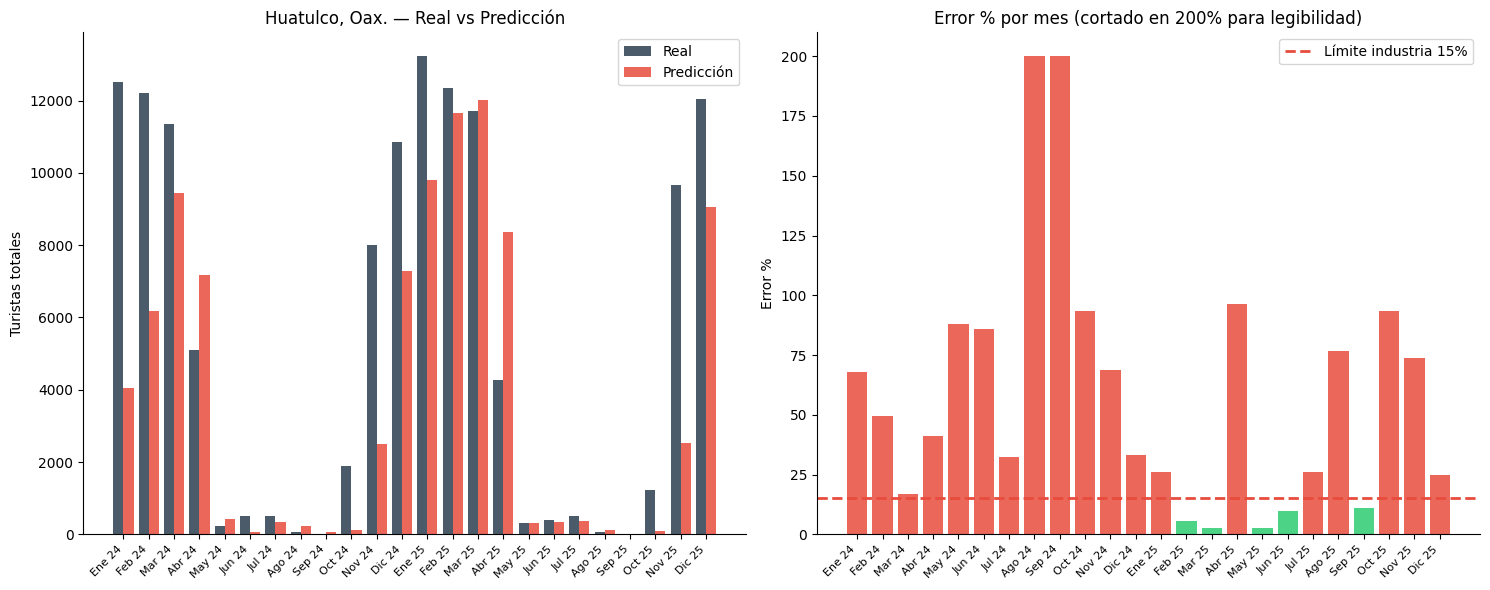


Temporada ALTA (real ≥50 turistas) — 22 meses:
  Error promedio: 61.7%
   Mes  Real   Prediccion  Error_pct
Ene 24 12519  4040.268416       67.7
Feb 24 12204  6167.939567       49.5
Mar 24 11341  9446.047169       16.7
Abr 24  5088  7180.230006       41.1
May 24   232   436.132648       88.0
Jun 24   517    72.646044       85.9
Jul 24   494   333.848425       32.4
Ago 24    52   230.398205      343.1
Sep 24    11    75.516276      586.5
Oct 24  1901   121.009806       93.6
Nov 24  7996  2493.743065       68.8
Dic 24 10859  7280.305901       33.0
Ene 25 13230  9807.233325       25.9
Feb 25 12343 11649.902938        5.6
Mar 25 11717 12031.496674        2.7
Abr 25  4268  8374.390428       96.2
May 25   315   307.057053        2.5
Jun 25   392   354.254449        9.6
Jul 25   494   365.145213       26.1
Ago 25    74   130.797287       76.8
Sep 25     3     2.670316       11.0
Oct 25  1226    81.140688       93.4
Nov 25  9679  2538.644667       73.8
Dic 25 12035  9064.708788       24.7

Te

In [9]:
AEROPUERTO_HX = 'huatulco, oax.'
candidatos = [a for a in test['Aeropuerto'].unique() if 'huatulco' in a or 'oax' in a]
print(f"Aeropuertos disponibles con 'huatulco'/'oax': {candidatos}")

hx_raw = test[test['Aeropuerto'] == AEROPUERTO_HX].copy()

if hx_raw.empty:
    print(f"⚠️ No encontrado. Cambia AEROPUERTO_HX por uno de: {candidatos}")
else:
    hx_raw['Prediccion'] = pred_test_series[hx_raw.index]

    hx_mes = hx_raw.groupby(['Año','MesNum']).agg(
        Real       = (TARGET, 'sum'),
        Prediccion = ('Prediccion', 'sum')
    ).reset_index().sort_values(['Año','MesNum'])
    hx_mes['Error_abs'] = abs(hx_mes['Real'] - hx_mes['Prediccion'])
    hx_mes['Error_pct'] = (hx_mes['Error_abs'] / hx_mes['Real'].clip(lower=1) * 100).round(1)
    hx_mes['Mes'] = (hx_mes['MesNum'].map(dict(enumerate(meses_lbl, 1))) +
                     ' ' + hx_mes['Año'].astype(str).str[-2:])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    x = range(len(hx_mes))
    axes[0].bar([i-.2 for i in x], hx_mes['Real'],      .4, color='#2c3e50', alpha=.85, label='Real')
    axes[0].bar([i+.2 for i in x], hx_mes['Prediccion'],.4, color='#e74c3c', alpha=.85, label='Predicción')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(hx_mes['Mes'], rotation=45, ha='right', fontsize=8)
    axes[0].set_title('Huatulco, Oax. — Real vs Predicción')
    axes[0].set_ylabel('Turistas totales')
    axes[0].legend()

    colores_hx = ['#e74c3c' if v > 15 else '#2ecc71' for v in hx_mes['Error_pct']]
    axes[1].bar(x, hx_mes['Error_pct'].clip(upper=200), color=colores_hx, alpha=.85)
    axes[1].axhline(y=15, color='#e74c3c', ls='--', lw=2, label='Límite industria 15%')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(hx_mes['Mes'], rotation=45, ha='right', fontsize=8)
    axes[1].set_title('Error % por mes (cortado en 200% para legibilidad)')
    axes[1].set_ylabel('Error %')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('rf_demo_huatulco.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Separar temporada alta vs baja
    hx_alta = hx_mes[hx_mes['Real'] >= 50]
    hx_baja = hx_mes[hx_mes['Real'] <  50]
    print(f"\nTemporada ALTA (real ≥50 turistas) — {len(hx_alta)} meses:")
    print(f"  Error promedio: {hx_alta['Error_pct'].mean():.1f}%")
    print(hx_mes[['Mes','Real','Prediccion','Error_pct']].to_string(index=False))
    print(f"\nTemporada BAJA (real <50 turistas) — {len(hx_baja)} meses:")
    print(f"  Error % no es métrica significativa (diferencias de 1–20 turistas en absoluto)")
    print(f"  Error ABSOLUTO promedio: {hx_baja['Error_abs'].mean():.0f} turistas")

## 10. Tabla comparativa de modelos

Esta tabla se guardará y el notebook de XGBoost la cargará para agregar su fila.
Al final del proyecto tendremos una comparación objetiva de todos los modelos
sobre los mismos datos de prueba.

In [10]:
tabla_modelos = pd.DataFrame([{
    'Modelo':              'Random Forest',
    'R² test (2024-25)':  metricas_test['r2'],
    'MAE test':           metricas_test['mae'],
    'RMSE test':          metricas_test['rmse'],
    'MAPE global (%)':    metricas_test['mape_global'],
    'MAPE negocio (%)':   metricas_test['mape_neg'],
    'Tiempo (s)':         TIEMPO_RF,
    'GPU':                'No',
    'n_estimators':       1000,
    'Features':           len(FEATURES),
    'Train años':         '2012-2023',
    'Estado':             '✅ Baseline'
}])

print("=" * 90)
print("TABLA COMPARATIVA DE MODELOS — Motor de Inteligencia Turística")
print("=" * 90)
print(tabla_modelos.to_string(index=False))
print("=" * 90)
print(f"\nEstándar industrial: MAPE negocio < 15%")
mape_n = metricas_test['mape_neg']
print(f"Random Forest MAPE negocio: {mape_n}% → {'✅ DENTRO' if mape_n < 15 else '⚠️ FUERA'} del estándar")

tabla_modelos.to_csv('comparacion_modelos.csv', index=False)
print("\n📄 Guardado: comparacion_modelos.csv (el notebook de XGBoost lo actualiza)")

TABLA COMPARATIVA DE MODELOS — Motor de Inteligencia Turística
       Modelo  R² test (2024-25)  MAE test  RMSE test  MAPE global (%)  MAPE negocio (%)  Tiempo (s) GPU  n_estimators  Features Train años     Estado
Random Forest             0.9856      72.1      868.2             37.3              17.1        26.2  No          1000        17  2012-2023 ✅ Baseline

Estándar industrial: MAPE negocio < 15%
Random Forest MAPE negocio: 17.1% → ⚠️ FUERA del estándar

📄 Guardado: comparacion_modelos.csv (el notebook de XGBoost lo actualiza)


## 11. Guardar modelo y resultados

In [11]:
# Modelo
with open('modelo_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Predicciones del test
pred_df = test[['Año','MesNum','Aeropuerto','Pais','Sexo',TARGET]].copy()
pred_df['Prediccion_RF'] = pred_test
pred_df['Error_abs']     = abs(pred_df[TARGET] - pred_df['Prediccion_RF'])
pred_df['Error_pct']     = (pred_df['Error_abs'] / pred_df[TARGET].clip(lower=1) * 100).round(1)
pred_df.to_csv('predicciones_rf.csv', index=False)

# Métricas en JSON para el notebook de XGBoost
metricas_json = {
    'Random Forest': {
        'r2_test':    metricas_test['r2'],
        'mae':        metricas_test['mae'],
        'rmse':       metricas_test['rmse'],
        'mape_global':metricas_test['mape_global'],
        'mape_neg':   metricas_test['mape_neg'],
        'tiempo_s':   TIEMPO_RF,
        'gpu':        False,
        'n_est':      1000,
        'features':   FEATURES
    }
}
with open('metricas_rf.json', 'w') as f:
    json.dump(metricas_json, f, indent=2)

# Resumen
archivos = ['modelo_rf.pkl','predicciones_rf.csv',
            'comparacion_modelos.csv','metricas_rf.json']
print("=" * 55)
print("ARCHIVOS GENERADOS")
print("=" * 55)
for a in archivos:
    if os.path.exists(a):
        print(f"  ✅ {a:<38} {os.path.getsize(a)/1024:>6.1f} KB")

print(f"\n{'='*55}")
print("RESUMEN FINAL — RANDOM FOREST")
print(f"{'='*55}")
print(f"  R² test:              {metricas_test['r2']}")
print(f"  MAE test:             {metricas_test['mae']:,.1f} turistas")
print(f"  MAPE global:          {metricas_test['mape_global']}%")
print(f"  MAPE negocio (≥50):   {metricas_test['mape_neg']}%")
print(f"  Tiempo entrenamiento: {TIEMPO_RF}s")
print(f"  Siguiente paso:       07_modelo_xgboost.ipynb")

ARCHIVOS GENERADOS
  ✅ modelo_rf.pkl                          4200144.1 KB
  ✅ predicciones_rf.csv                    6325.6 KB
  ✅ comparacion_modelos.csv                   0.2 KB
  ✅ metricas_rf.json                          0.6 KB

RESUMEN FINAL — RANDOM FOREST
  R² test:              0.9856
  MAE test:             72.1 turistas
  MAPE global:          37.3%
  MAPE negocio (≥50):   17.1%
  Tiempo entrenamiento: 26.2s
  Siguiente paso:       07_modelo_xgboost.ipynb
